In [31]:
import pandas as pd
import matplotlib.pyplot as plt

results1 = pd.read_csv("runs/detect/train/results.csv")
results2 = pd.read_csv("runs/detect/train2/results.csv")
metric_name = "metrics/mAP50-95(B)"

metric_epochs = results1[["epoch", metric_name]].join(results2[metric_name], rsuffix="_2")
filter_epochs = (metric_epochs["epoch"] == 1) | (metric_epochs["epoch"] % 5 == 0)
simple_results = metric_epochs[filter_epochs]

simple_results.to_csv("results/train_metrics.csv")

simple_results

,epoch,metrics/mAP50-95(B),metrics/mAP50-95(B)_2
0,1,0.07164,0.36041
4,5,0.68053,0.69801
9,10,0.73635,0.74538
14,15,0.75135,0.76585
19,20,0.76205,0.77663
24,25,0.76883,0.78710
29,30,0.77499,0.79338
34,35,0.77618,0.79788
39,40,0.77979,0.80150
44,45,0.78233,0.80437


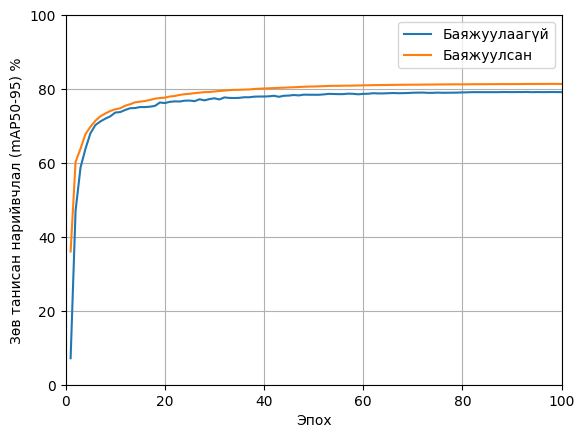

In [32]:
plt.plot(metric_epochs["epoch"], metric_epochs[metric_name] * 100)
plt.plot(metric_epochs["epoch"], metric_epochs[metric_name + "_2"] * 100)
plt.xlabel("Эпох")
plt.ylabel("Зөв танисан нарийвчлал (mAP50-95) %")
ax = plt.gca()
ax.set_xlim([0, 100])
ax.set_ylim([0, 100])
plt.legend(["Баяжуулаагүй", "Баяжуулсан"])
plt.grid()
plt.show()